In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("amazon_sales_dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(50000, 13)
Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [3]:
cols_to_drop = ["order_id", "product_id", "discounted_price", "quantity_sold"]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [4]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day

df = df.drop(columns=["order_date"])

In [5]:
df = df.dropna()

In [6]:
df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop("total_revenue", axis=1)
y = df["total_revenue"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

In [11]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=4,
    verbose=2
)

In [12]:
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [13]:
rf = grid.best_estimator_
y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 266.51452575146453
RMSE: 359.3261741544621
R2 Score: 0.5238082826904028


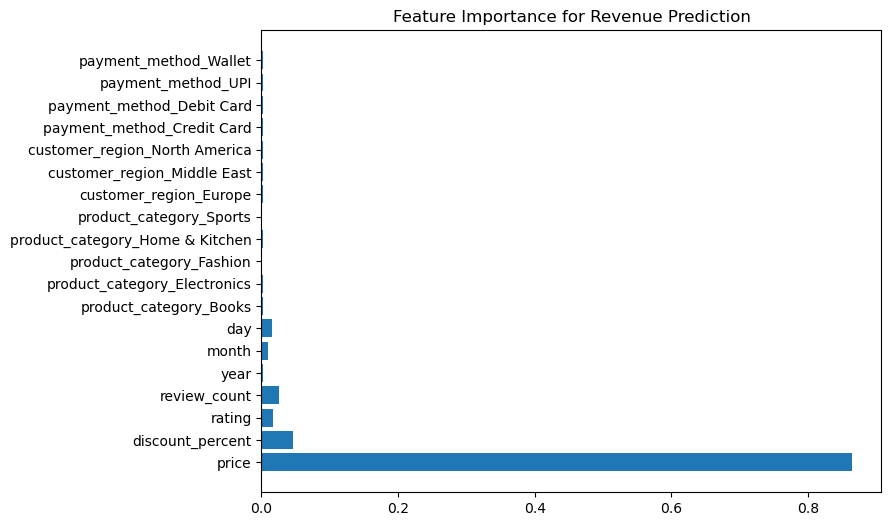

In [14]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("Feature Importance for Revenue Prediction")
plt.show()

In [15]:
import joblib

# Save trained model
joblib.dump(rf, "revenue_model.pkl")

# Save feature column order (VERY IMPORTANT)
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model and feature list saved successfully!")

Model and feature list saved successfully!
